# From a map pin to a procedural neighborhood

Inspired by **Map Pin to 3D Neighborhood**, Pietro Schirano:
[catalog](https://github.com/magiccreator-ai/awesome-gpt-6-astra#map-pin-to-3d-neighborhood) ·
[creator post](https://x.com/skirano/status/2095899479308144981), and **Seoul 3D Atlas**, synabreu:
[catalog](https://github.com/magiccreator-ai/awesome-gpt-6-astra#seoul-3d-atlas) ·
[creator demo](https://seoul-3d-atlas.synabreu.chatgpt.site/).
[Our interactive city](https://jltobias.github.io/JupyterLite-Astra-demos/demos/?scene=city)

**Learn:** separate geographic coordinates, local coordinates, footprints and heights.
**Predict:** which extra information does a footprint need before it becomes a 3D building?
The pin is near Seoul; **every building is invented**. The pin provides a coordinate origin only.
This small-area tangent approximation is not a cadastral projection or a city reconstruction.


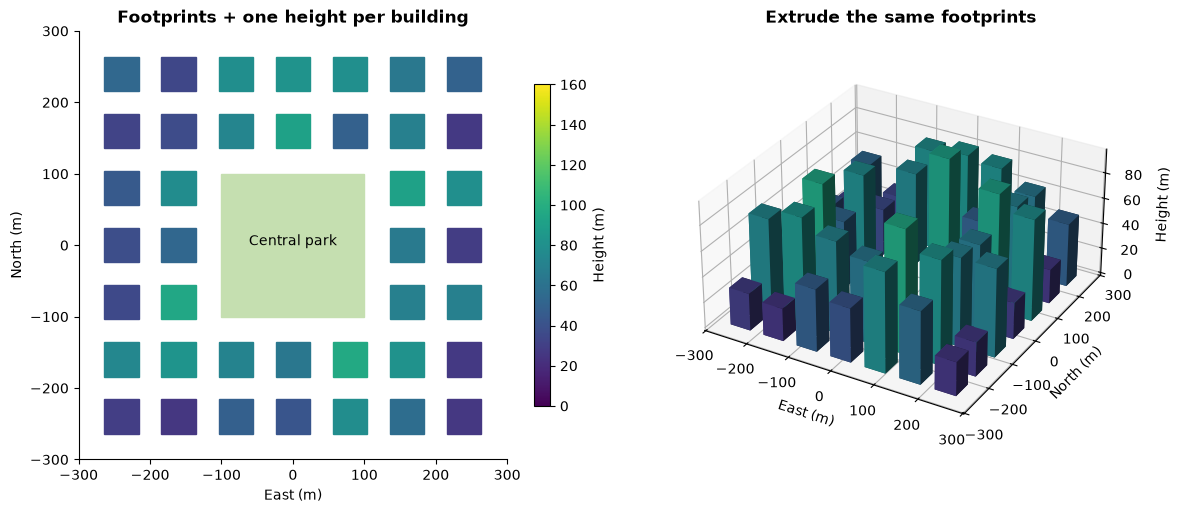

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
from astra_utils import style
style()
rng = np.random.default_rng(12)
lon0, lat0 = 126.978, 37.5665
R = 6371000
def to_lonlat(east, north):
    return lon0 + np.rad2deg(east/(R*np.cos(np.deg2rad(lat0)))), lat0 + np.rad2deg(north/R)
def to_local(lon, lat):
    return R*np.deg2rad(lon-lon0)*np.cos(np.deg2rad(lat0)), R*np.deg2rad(lat-lat0)

xy = np.array([(x,y) for x in range(-240,241,80) for y in range(-240,241,80) if not (abs(x)<90 and abs(y)<90)])
height = rng.uniform(12,70,len(xy)) + 90*np.exp(-np.sum(xy**2,axis=1)/180**2)
width = 48.0
norm = Normalize(0,160)
colors = plt.colormaps['viridis'](norm(height))
fig = plt.figure(figsize=(12, 5))
plan = fig.add_subplot(121)
for (x,y), h, color in zip(xy,height,colors):
    plan.add_patch(Rectangle((x-width/2,y-width/2),width,width,color=color))
plan.add_patch(Rectangle((-100,-100),200,200,color='#c5dfb0'))
plan.text(0,0,'Central park',ha='center')
plan.set(xlim=(-300,300),ylim=(-300,300),aspect='equal',xlabel='East (m)',ylabel='North (m)',title='Footprints + one height per building')
fig.colorbar(plt.cm.ScalarMappable(norm=norm,cmap='viridis'),ax=plan,label='Height (m)',shrink=.75)
ax = fig.add_subplot(122,projection='3d')
ax.bar3d(xy[:,0]-width/2,xy[:,1]-width/2,np.zeros(len(xy)),width,width,height,color=colors,shade=True)
ax.set(xlabel='East (m)',ylabel='North (m)',zlabel='Height (m)',title='Extrude the same footprints')
ax.set_box_aspect((1,1,.5))
fig.tight_layout()
plt.show()


**Visual bridge:** identical colors identify the same height in both views. The footprint fixes
horizontal extent; extrusion adds a vertical dimension. A map pin alone contains neither.

GeoJSON coordinates use `[longitude, latitude]`, while a scene usually uses meters. Mixing these
produces distorted buildings. We will export closed footprint rings and keep height as a property.


In [2]:
features = []
for i, ((x,y), h) in enumerate(zip(xy,height)):
    corners = [(x-width/2,y-width/2),(x+width/2,y-width/2),(x+width/2,y+width/2),(x-width/2,y+width/2),(x-width/2,y-width/2)]
    ring = [[float(v) for v in to_lonlat(*p)] for p in corners]
    features.append({'type':'Feature','properties':{'id':i,'height_m':round(float(h),2),'synthetic':True},
                     'geometry':{'type':'Polygon','coordinates':[ring]}})
geojson = {'type':'FeatureCollection','features':features}
with open('synthetic_neighborhood.geojson','w',encoding='utf-8') as f:
    json.dump(geojson,f,indent=2)
print(f'Exported {len(features)} invented buildings to synthetic_neighborhood.geojson')
print('First coordinate (longitude, latitude):', features[0]['geometry']['coordinates'][0][0])
assert np.allclose(to_local(*to_lonlat(xy[:,0],xy[:,1])), xy.T)
assert all(f['geometry']['coordinates'][0][0] == f['geometry']['coordinates'][0][-1] for f in features)


Exported 40 invented buildings to synthetic_neighborhood.geojson
First coordinate (longitude, latitude): [126.97500470539389, 37.564125790960375]


**Experiment:** change `lat0` to 0, then rerun. The local meter scene is unchanged, but longitude
spans shrink near the equator. Change the seed to generate a different skyline with the same street plan.
Download the exported GeoJSON through JupyterLite's file browser to inspect it in a GIS.

**Explain:** what would be needed for a faithful city? Surveyed footprints, a suitable CRS,
measured heights, terrain elevations, timestamps and provenance. Attractive geometry is not evidence
that these inputs were available. Continue to notebook 15 to add sunlight and shadows.
